# Estações Climáticas
## Síntese dos dados

### Como usar:
- input_folder - Colocar caminho da pasta onde estão as planilhas baixadas
- output_file - Colocar caminho onde você quer que sejam colocados os dados compilados
- station_code - Inserir código da estação da qual deseja-se as informações

83907
Erro ao processar o arquivo dados_compilados_83907.xlsx: 'Código '
Evaporação total (Evaporímetro Piche)(mm)
Insolação Total (horas)
Precipitação Acumulada Mensal e Anual (mm)
Número de dias no mês ou no ano com precipitação maior ou igual a (1 mm) (dias)
Temperatura Máxima Mensal e Anual (°C)
Temperatura Média Compensada Mensal e Anual (°C)
Temperatura Mínima Mensal e Anual (°C)
Umidade Relativa do Ar Compensada Mensal e Anual (%)
Intensidade do Vento (m.s-¹)
Direção Predominante do vento (Pontos cardeais e colaterais)
Erro ao processar o arquivo ~$Normal-Climatologica-PREC.xlsx: [Errno 13] Permission denied: 'C:\\Users\\gabriel.coimbra\\Desktop\\Meus arquivos\\São Pedro do Sul\\Clima\\~$Normal-Climatologica-PREC.xlsx'


2,Código,Nome da Estação,UF,Janeiro,Fevereiro,Março,Abril,Maio,Junho,Julho,Agosto,Setembro,Outubro,Novembro,Dezembro,Ano,Informação
0,83997,SANTA VITORIA DO PALMAR,RS,135.3,109.8,104.1,82.1,60.6,50.6,51.5,59.8,71,88.5,116.3,133.8,1063.4,Evaporação total (Evaporímetro Piche)(mm)
1,83997,SANTA VITORIA DO PALMAR,RS,257.5,212,211.5,175.5,151.1,132.7,143.1,155.5,161.8,196.5,233.9,253.2,2284.3,Insolação Total (horas)
2,83997,SANTA VITORIA DO PALMAR,RS,81.4,128,116.4,123.3,119.2,113.1,112.7,108.2,97,102.4,70,91.5,1263.2,Precipitação Acumulada Mensal e Anual (mm)
3,83997,SANTA VITORIA DO PALMAR,RS,6,8,7,7,7,8,7,8,7,8,6,7,86,Número de dias no mês ou no ano com precipitaç...
4,83997,SANTA VITORIA DO PALMAR,RS,27.8,27.4,26.2,23.3,19.7,16.8,15.9,17.6,18.7,21.3,24,26.5,22.1,Temperatura Máxima Mensal e Anual (°C)
5,83997,SANTA VITORIA DO PALMAR,RS,22.6,22.4,21.1,18.1,14.8,12.1,11.2,12.5,13.8,16.4,18.7,21.1,17.1,Temperatura Média Compensada Mensal e Anual (°C)
6,83997,SANTA VITORIA DO PALMAR,RS,18.4,18.3,17.1,14.3,11.2,8.6,7.8,8.8,10,12.5,14.4,16.7,13.2,Temperatura Mínima Mensal e Anual (°C)
7,83997,SANTA VITORIA DO PALMAR,RS,75.2,77.6,79.6,81.2,84.3,85.1,84.5,83.6,81.8,80.1,75.7,74.5,80.3,Umidade Relativa do Ar Compensada Mensal e Anu...


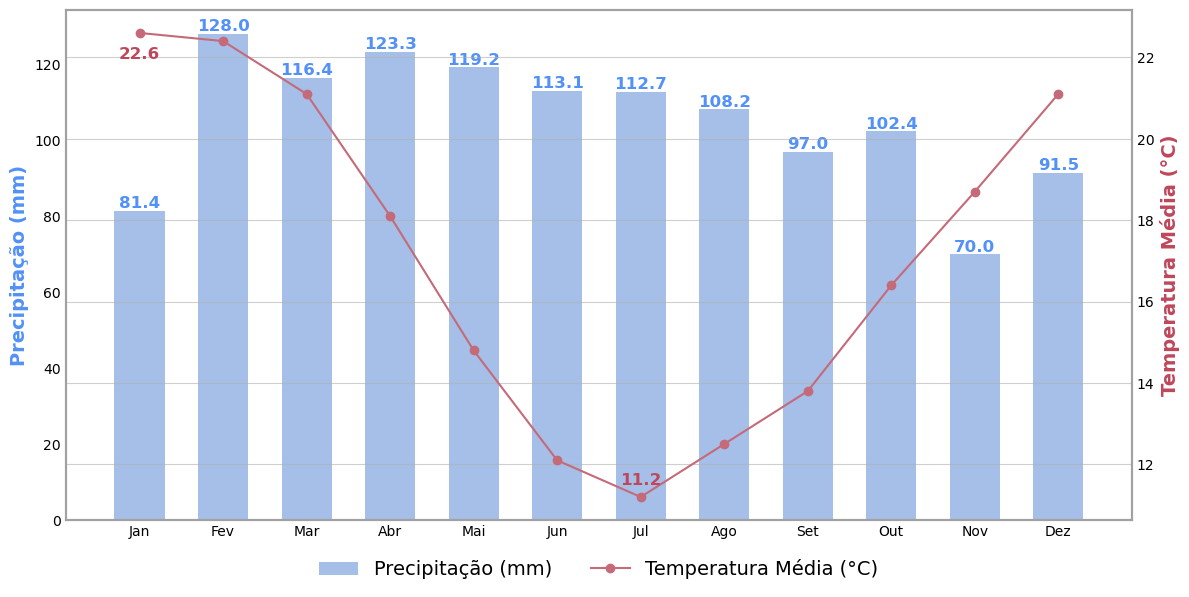

In [83]:
# Diretório onde estão os arquivos Excel
input_folder = r"C:\Users\gabriel.coimbra\Desktop\Meus arquivos\São Pedro do Sul\Clima"
# Código da estação desejada
station_code = 83997 # Substitua pelo código da estação desejada

output_file = rf"C:\Users\gabriel.coimbra\Desktop\Meus arquivos\São Pedro do Sul\Clima\dados_compilados_{str(station_code)}.xlsx"

########################################################################
########################################################################
########################################################################

import os
import pandas as pd

# Lista para armazenar os dados filtrados
dataframes = []

# Loop para processar cada arquivo Excel
for file_name in os.listdir(input_folder):
    if file_name.endswith(".xlsx"):
        file_path = os.path.join(input_folder, file_name)
        
        # Ler o arquivo Excel
        try:
            df = pd.read_excel(file_path, header=None)

            # Obter o título da linha 2 (índice 1)
            title = df.iloc[1, 0]
            print(title)

            # Definir a linha 3 (índice 2) como cabeçalho
            df.columns = df.iloc[2]
            df = df[3:]

            # Adicionar a coluna do título
            df["Informação"] = title

            # Filtrar os dados pela estação desejada
            filtered_df = df[df["Código "] == station_code]
            
            # Adicionar ao dataframe consolidado
            dataframes.append(filtered_df)


        except Exception as e:
            print(f"Erro ao processar o arquivo {file_name}: {e}")

# Concatenar todos os dataframes filtrados
if dataframes:
    final_df = pd.concat(dataframes, ignore_index=True)
    display(final_df)
    # Salvar em um único arquivo Excel
    #final_df.to_excel(output_file, index=False)
    #print(f"Dados compilados salvos em: {output_file}")
#else:
    #print("Nenhum dado foi compilado.")

########################################################################
########################################################################
########################################################################

import pandas as pd
import matplotlib.pyplot as plt

# Função para gerar o gráfico automaticamente a partir de final_df
def gerar_grafico(final_df):

    # Extrair dados de Precipitação e Temperatura Média Compensada
    dados_precip = final_df[final_df["Informação"] == "Precipitação Acumulada Mensal e Anual (mm)"]
    dados_temp = final_df[final_df["Informação"] == "Temperatura Média Compensada Mensal e Anual (°C)"]
    
    if dados_precip.empty or dados_temp.empty:
        print(f"Dados incompletos.")
        return
    
    # Selecionar apenas os valores dos meses
    meses = ["Janeiro", "Fevereiro", "Março", "Abril", "Maio", "Junho", 
             "Julho", "Agosto", "Setembro", "Outubro", "Novembro", "Dezembro"]
    precip = dados_precip[meses].values.flatten()
    temp = dados_temp[meses].values.flatten()
    
    # Configurar os meses no eixo X
    labels_meses = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", 
                    "Jul", "Ago", "Set", "Out", "Nov", "Dez"]
    
    # Encontrar valores máximos e mínimos da temperatura
    temp_max = max(temp)
    temp_min = min(temp)
    idx_max = temp.tolist().index(temp_max)
    idx_min = temp.tolist().index(temp_min)
    
    # Criar o gráfico
    fig, ax1 = plt.subplots(figsize=(12, 6))
    # Alterar a cor do contorno do gráfico para cinza escuro
    for spine in ax1.spines.values():
        spine.set_edgecolor("#a1a1a1")
        spine.set_linewidth(1.5)  # Ajustar a espessura do contorno
        
    # Gráfico de barras para precipitação
    bars = ax1.bar(labels_meses, precip, color="#a5bfe8", label="Precipitação (mm)", width=0.6)
    
    # Adicionar valores em cima das barras
    for bar, value in zip(bars, precip):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{value:.1f}", 
                 ha="center", va="bottom", fontsize=12, color="#5291f7", fontweight='bold')
    
    # Adicionar título e rótulo do eixo Y de precipitação
    ax1.set_ylabel("Precipitação (mm)", fontsize=14, color="#5291f7", fontweight='bold')

    # Gráfico de linha para temperatura média
    ax2 = ax1.twinx()
    ax2.plot(labels_meses, temp, color="#c46a79", marker="o", label="Temperatura Média (°C)")
    for spine in ax2.spines.values():
        spine.set_edgecolor("#a1a1a1")
        spine.set_linewidth(1.5)
    # Adicionar grid horizontal
    ax2.grid(axis='y', alpha=0.6)
    
    # Adicionar valores SOMENTE nos pontos de temperatura máxima e mínima
    ax2.text(idx_max, temp_max - 0.7, f"{temp_max:.1f}", 
             ha="center", va="bottom", fontsize=12, color="#bf475b", fontweight='bold')
    
    ax2.text(idx_min, temp_min + 0.6, f"{temp_min:.1f}", 
             ha="center", va="top", fontsize=12, color="#bf475b", fontweight='bold')
    
    # Adicionar título e rótulo do eixo Y de temperatura
    ax2.set_ylabel("Temperatura Média (°C)", fontsize=14, color="#bf475b", fontweight='bold')

    # **Remover os tracinhos (ticks) dos eixos, mas manter os eixos visíveis**
    ax1.tick_params(axis='both', length=0)  # Remove ticks de X e Y do eixo de precipitação
    ax2.tick_params(axis='y', length=0)  # Remove ticks do eixo de temperatura
    
    # Adicionar legendas sem box na parte inferior
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    plt.legend(lines + lines2, labels + labels2, loc="lower center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False, fontsize=14)
    
    # Ajustar o layout para evitar cortes
    fig.tight_layout()
    
    # Mostrar o gráfico
    plt.savefig(rf'{input_folder}\{str(station_code)}_gráfico.png')
    plt.show()

# Exemplo de uso com o DataFrame final_df
gerar_grafico(final_df)

#### Com isso, rode o código (shift + enter)